In [2]:
import os
import glob
import fnmatch
import pandas as pd
import matplotlib.pyplot as plt
import librosa
import librosa.display
import numpy as np
import seaborn as sns
import IPython.display as ipd
import random

from imblearn.over_sampling import SMOTE

from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.layers import Conv1D, Conv2D, SeparableConv1D, MaxPooling1D, MaxPooling2D
from tensorflow.keras.layers import Input, add, Flatten, Dense, BatchNormalization, Dropout, LSTM, GRU, SimpleRNN, LSTM
from tensorflow.keras.layers import GlobalMaxPooling1D, GlobalMaxPooling2D, Activation, LeakyReLU, ReLU, Dropout

from tensorflow.keras import regularizers
from tensorflow.keras import backend as K
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.preprocessing.sequence import pad_sequences

from sklearn import preprocessing
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,matthews_corrcoef
from sklearn.metrics import cohen_kappa_score,roc_auc_score,confusion_matrix,classification_report

In [3]:
df = pd.read_csv("hasta_etiketler.csv", sep=";")
df["Teshis"] = df["Teshis"].replace({
    "COPD4": "COPD",
    "COPD3": "COPD",
    "COPD2": "COPD",
    "COPD0": "COPD",
})
label_dict = dict(zip(df["ID"], df["Teshis"]))
label_dict["H001"] = "Healthy" 
label_dict

{'H001': 'Healthy',
 'H002': 'COPD',
 'H003': 'COPD',
 'H004': 'COPD',
 'H005': 'COPD',
 'H006': 'COPD',
 'H007': 'COPD',
 'H008': 'COPD',
 'H009': 'COPD',
 'H010': 'COPD',
 'H011': 'COPD',
 'H012': 'COPD',
 'H013': 'COPD',
 'H014': 'COPD',
 'H015': 'COPD',
 'H016': 'COPD',
 'H017': 'COPD1',
 'H018': 'COPD',
 'H019': 'Asthma',
 'H020': 'Asthma',
 'H021': 'COPD',
 'H022': 'COPD',
 'H023': 'COPD',
 'H024': 'COPD',
 'H025': 'COPD',
 'H026': 'COPD',
 'H027': 'Asthma',
 'H028': 'COPD',
 'H029': 'COPD1',
 'H030': 'COPD',
 'H031': 'COPD',
 'H032': 'COPD',
 'H033': 'COPD',
 'H034': 'COPD',
 'H035': 'COPD',
 'H036': 'COPD',
 'H037': 'COPD',
 'H038': 'COPD',
 'H039': 'COPD1',
 'H040': 'COPD',
 'H041': 'COPD',
 'H042': 'COPD',
 'H043': 'COPD1',
 'H044': 'COPD',
 'H045': 'COPD1',
 'H046': 'Asthma',
 'H047': 'Asthma',
 'H048': 'Healthy',
 'H049': 'Healthy',
 'H050': 'COPD',
 'H051': 'Asthma',
 'H052': 'Healthy',
 'H053': 'Healthy',
 'H054': 'Healthy',
 'H055': 'Healthy',
 'H056': 'Healthy',
 'H057'

In [4]:
asthma_data = "./Datalar/Asthma"
copd_data = "./Datalar/COPD4"
healthy_data = "./Datalar/Healthy"

print("Asthma files:", len(os.listdir(asthma_data)))
print("COPD files:", len(os.listdir(copd_data)))
print("Healthy files:", len(os.listdir(healthy_data)))

Asthma files: 96
COPD files: 112
Healthy files: 112


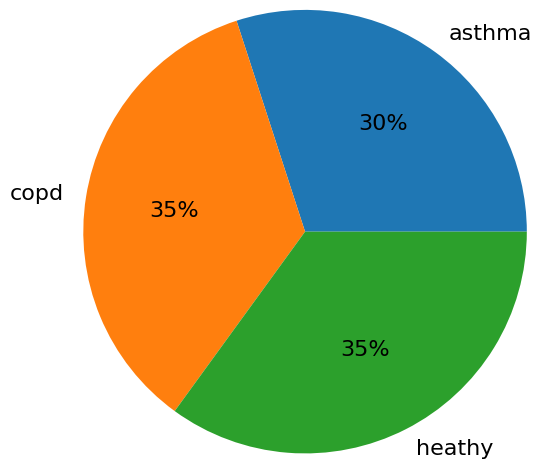

In [5]:
x = np.array([len(os.listdir(asthma_data)),
              len(os.listdir(copd_data)),
              len(os.listdir(healthy_data))])
labels = ['asthma', 'copd', 'heathy']
plt.pie(x, labels = labels, autopct = '%.0f%%', radius= 1.5, textprops={'fontsize': 16})
plt.show()

In [6]:
def random_sound (audio_class):
    random_sound = np.random.randint(0,len(os.listdir(audio_class))) 
    sound = os.listdir(audio_class)[random_sound]
    sound = audio_class+"/"+sound
    sound,sample_rate = librosa.load(sound)
    return ipd.Audio(sound,rate=sample_rate),sound

def show_audio_waveform(audio_sample):
    plt.figure(figsize=(20,5))
    librosa.display.waveshow(audio_sample, sr = 22050)
    plt.xlabel("Time")
    plt.ylabel("Amplitude")
    plt.show()

def show_audio_spectrum(audio_sample):
    sample_rate = 22050
    fft_normal = np.fft.fft(audio_sample)
    magnitude_normal = np.abs(fft_normal)
    freq_normal = np.linspace(0,sample_rate, len(magnitude_normal)) 
    half_freq = freq_normal[:int(len(freq_normal)/2)]
    half_magnitude = magnitude_normal[:int(len(freq_normal)/2)]

    plt.figure(figsize=(12,8))
    plt.plot(half_freq,half_magnitude)
    plt.title("Spectrum")
    plt.xlabel("Frequency")
    plt.ylabel("Magnitude")
    plt.show()

def show_spectrogram (audio_sample):
    hop_length = 512
    n_fft = 2048
    sample_rate = 22050

    hop_length_duration = float(hop_length)/sample_rate
    n_fft_duration = float(n_fft)/sample_rate

    print("STFT hop length duration is: {}s".format(hop_length_duration))
    print("STFT window duration is: {}s".format(n_fft_duration))

    stft_normal = librosa.stft(audio_sample, n_fft=n_fft, hop_length=hop_length)

    spectrogram = np.abs(stft_normal)
    log_spectrogram = librosa.amplitude_to_db(spectrogram)

    plt.figure(figsize=(15,10))
    librosa.display.specshow(log_spectrogram, sr=sample_rate, hop_length=hop_length)
    plt.xlabel("Time")
    plt.ylabel("Frequency")
    plt.colorbar()
    #plt.set_cmap("YlOrBr")
    plt.title("Spectrogram")

def show_mfcc_features(audio_sample):
    hop_length = 512
    n_fft = 2048
    sample_rate = 22050
    
    MFCCs = librosa.feature.mfcc(y=audio_sample, sr=sample_rate, n_fft=n_fft, hop_length=hop_length, n_mfcc=52)

    # display MFCCs
    plt.figure(figsize=(15,10))
    librosa.display.specshow(MFCCs, x_axis='time', sr=sample_rate, hop_length=hop_length)
    plt.xlabel("Time")
    plt.ylabel("MFCC coefficients")
    plt.colorbar()
    plt.title("MFCCs")
    plt.show()

In [7]:
asthma_audio, asthma_sample  = random_sound(asthma_data)
asthma_audio

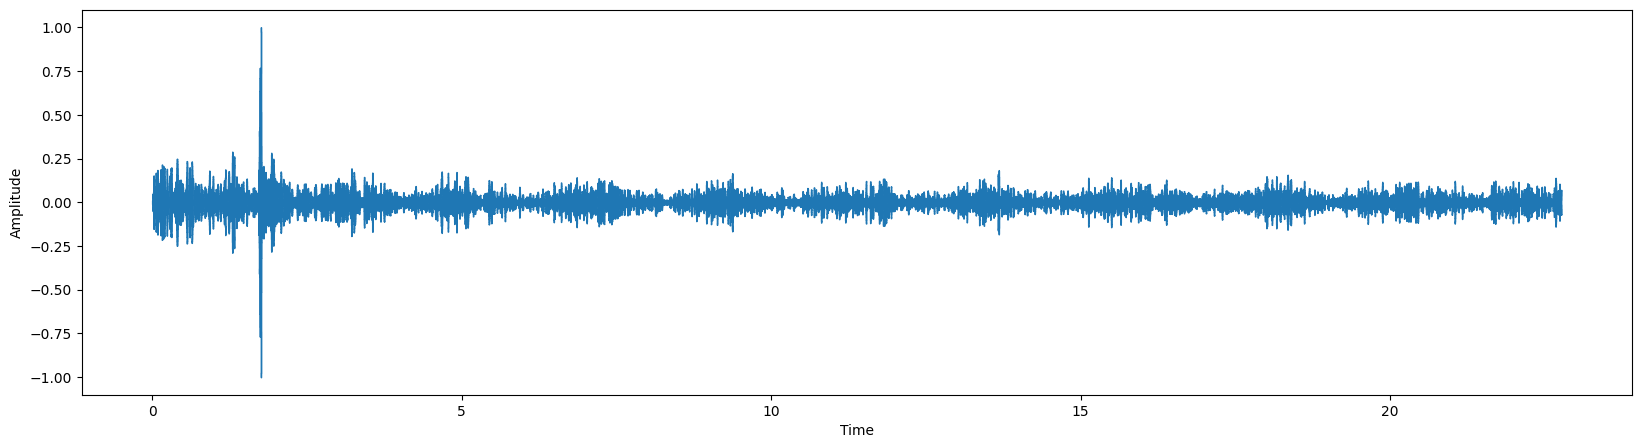

In [8]:
show_audio_waveform(asthma_sample)

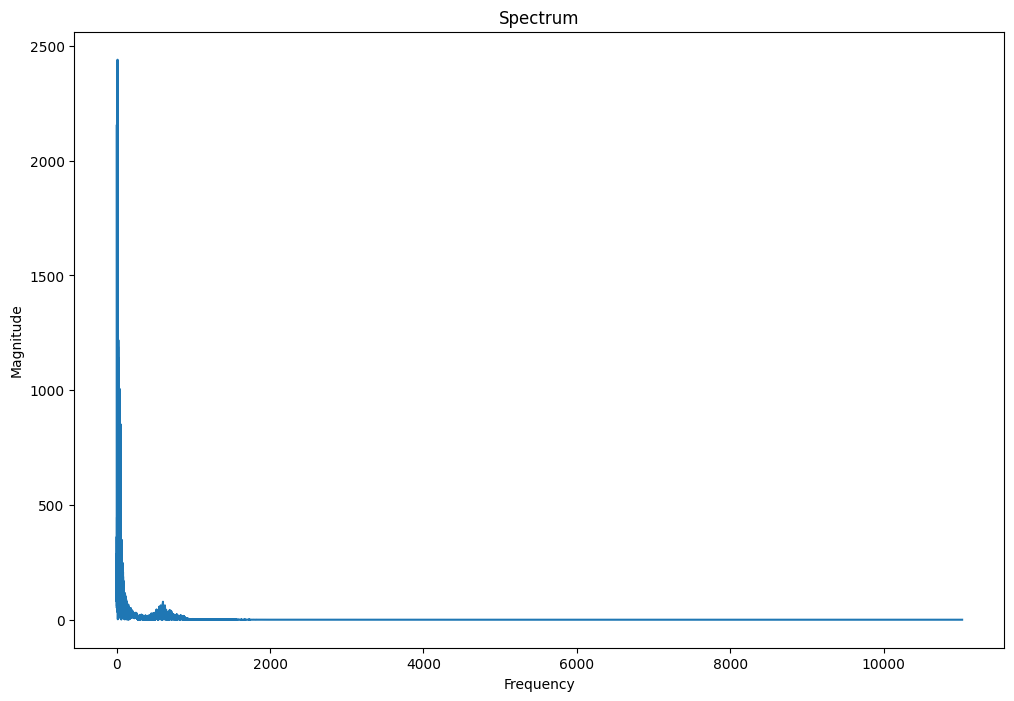

In [9]:
show_audio_spectrum(asthma_sample)

STFT hop length duration is: 0.023219954648526078s
STFT window duration is: 0.09287981859410431s


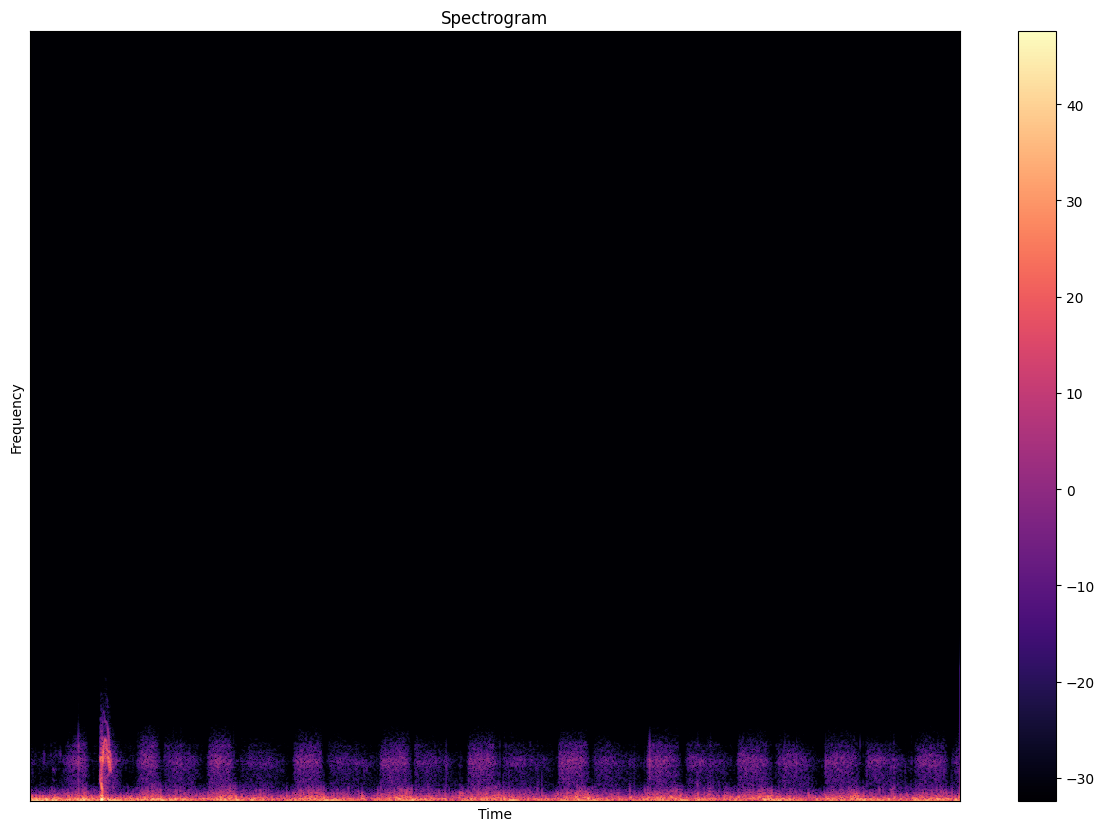

In [10]:
show_spectrogram(asthma_sample)

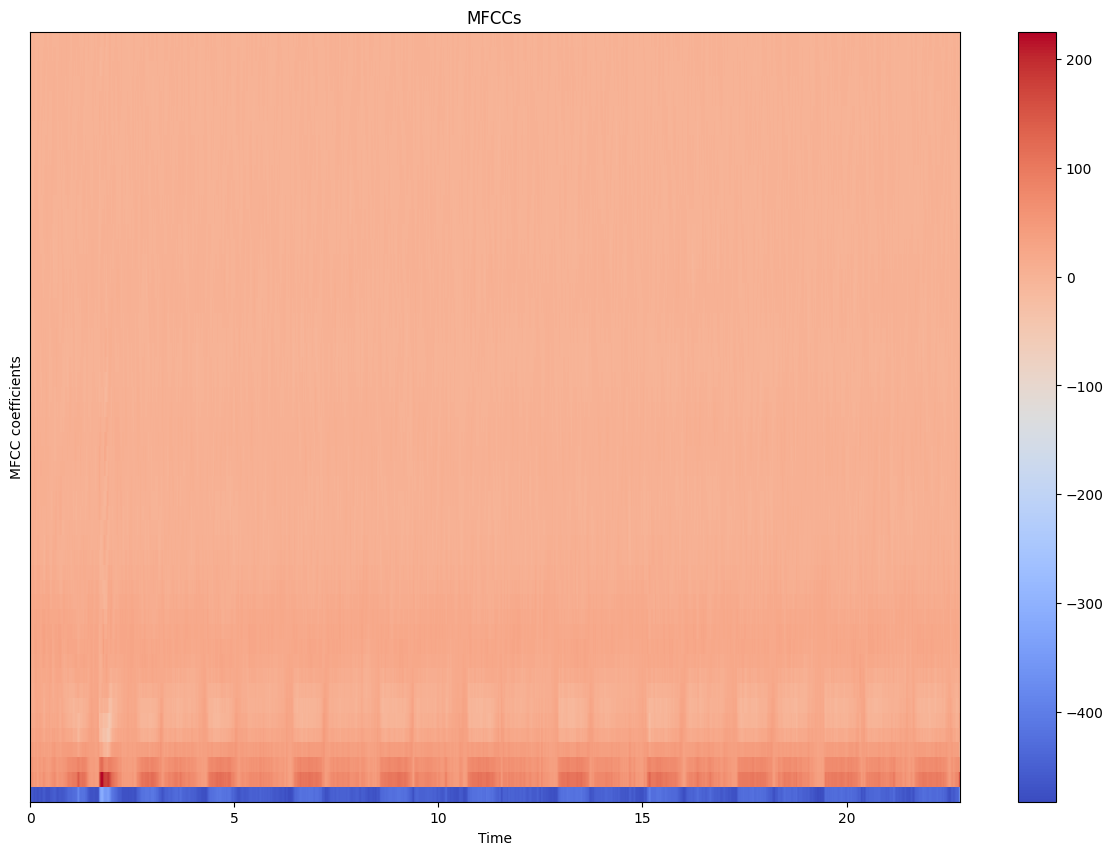

In [11]:
show_mfcc_features(asthma_sample)

In [12]:
copd_audio, copd_sample = random_sound(copd_data)
copd_audio

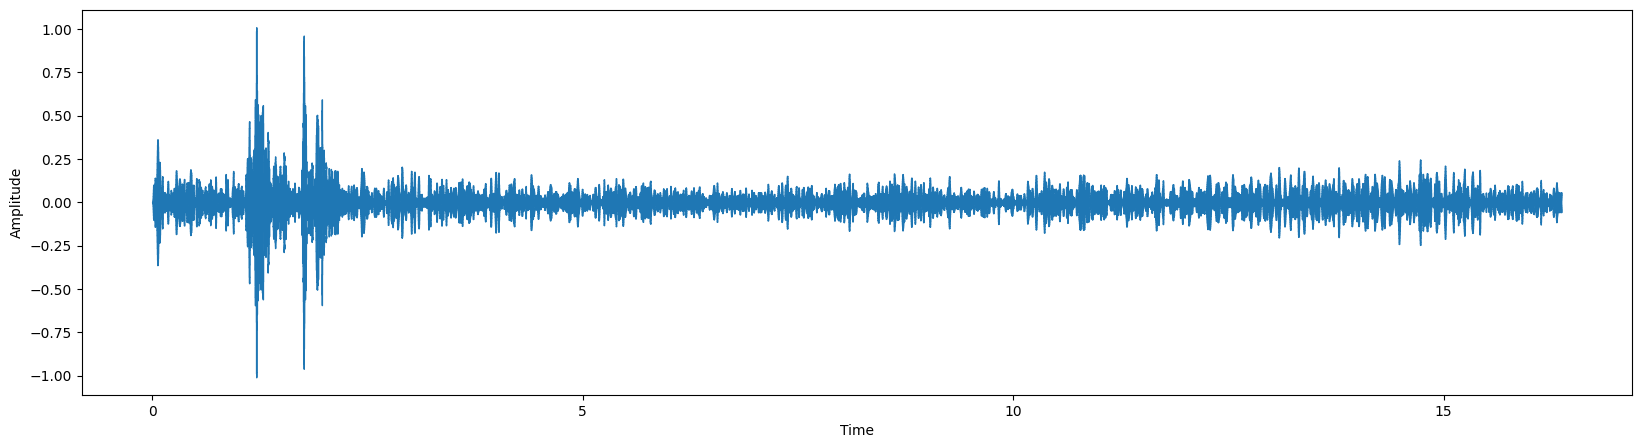

In [13]:
show_audio_waveform(copd_sample)

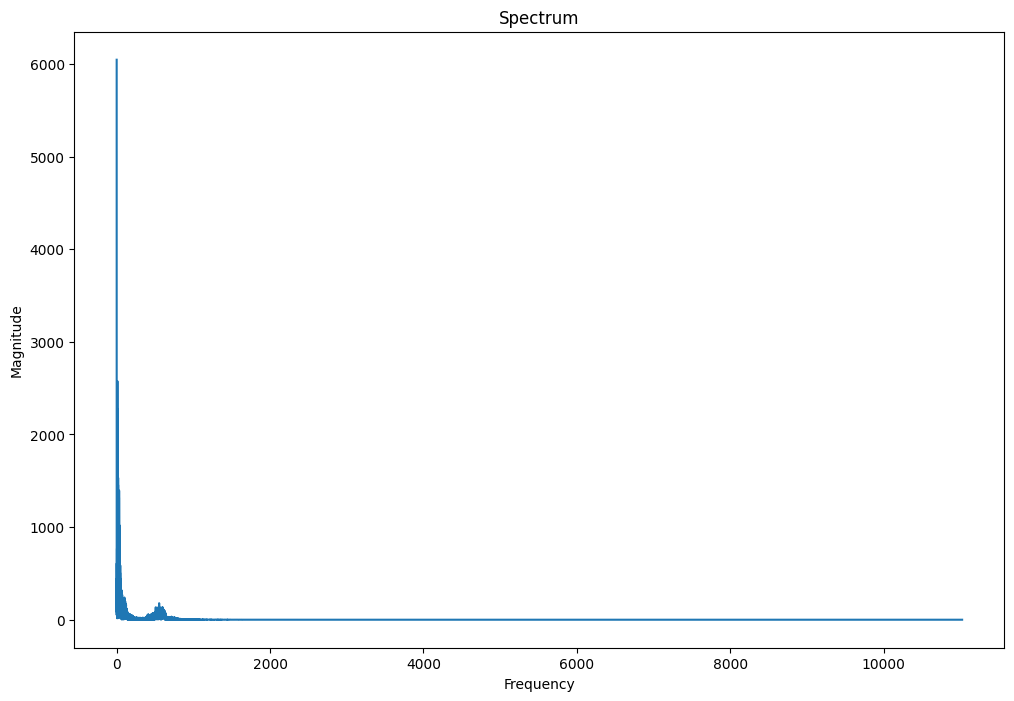

In [14]:
show_audio_spectrum(copd_sample)

STFT hop length duration is: 0.023219954648526078s
STFT window duration is: 0.09287981859410431s


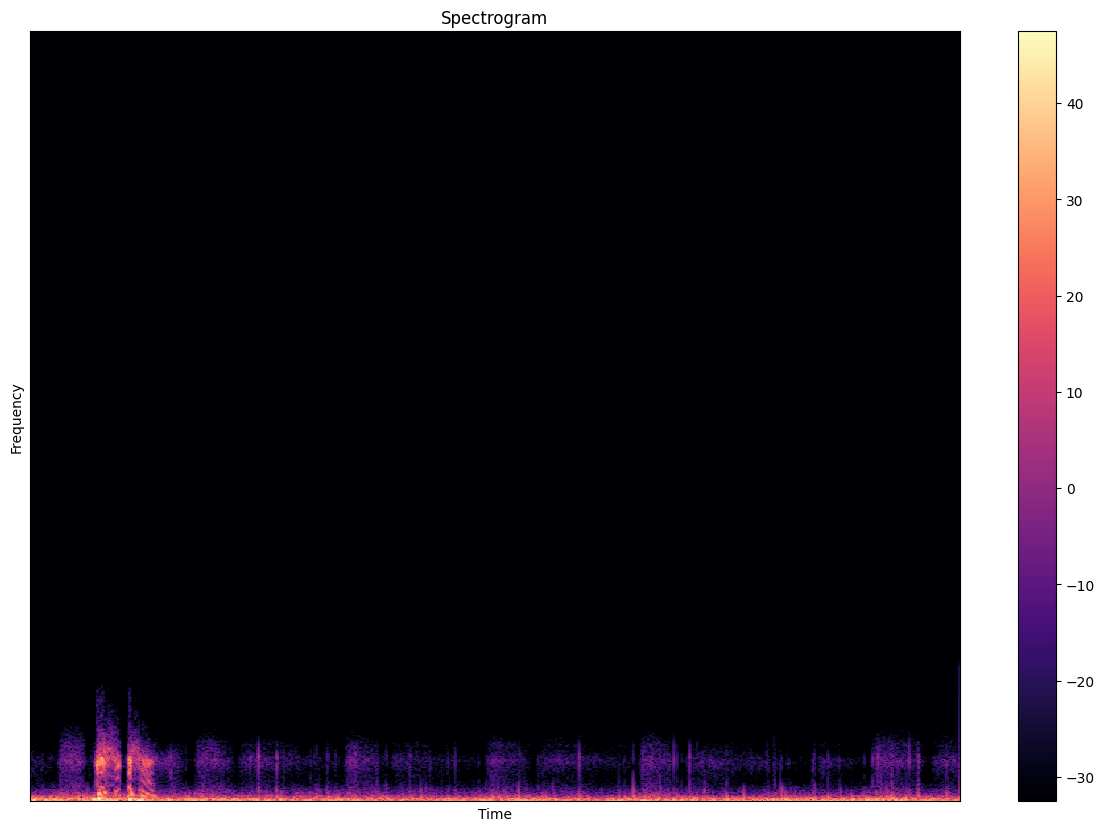

In [15]:
show_spectrogram(copd_sample)

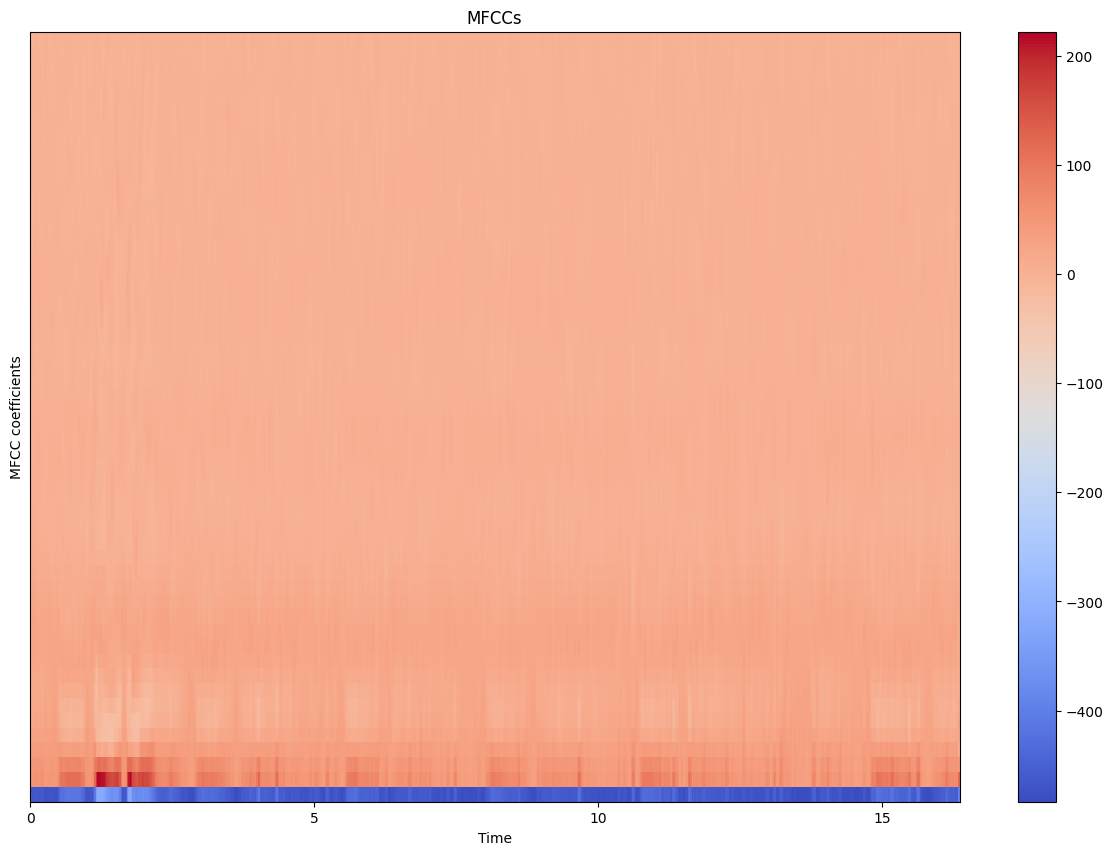

In [16]:
show_mfcc_features(copd_sample)

In [17]:
healthy_audio,healthy_sample = random_sound(healthy_data)
healthy_audio

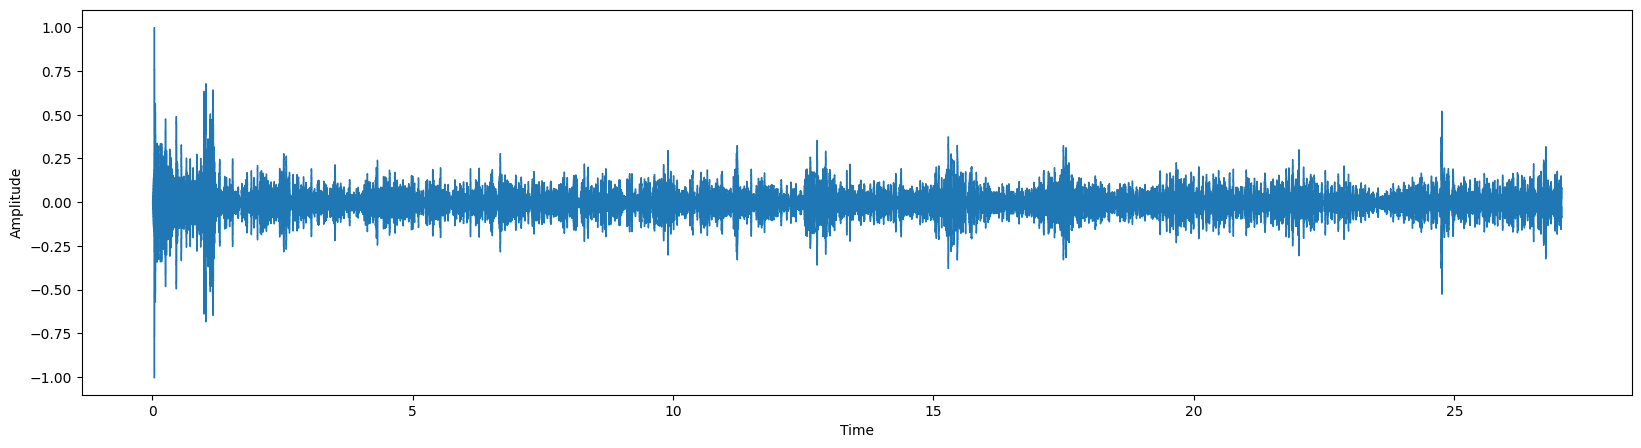

In [18]:
show_audio_waveform(healthy_sample)

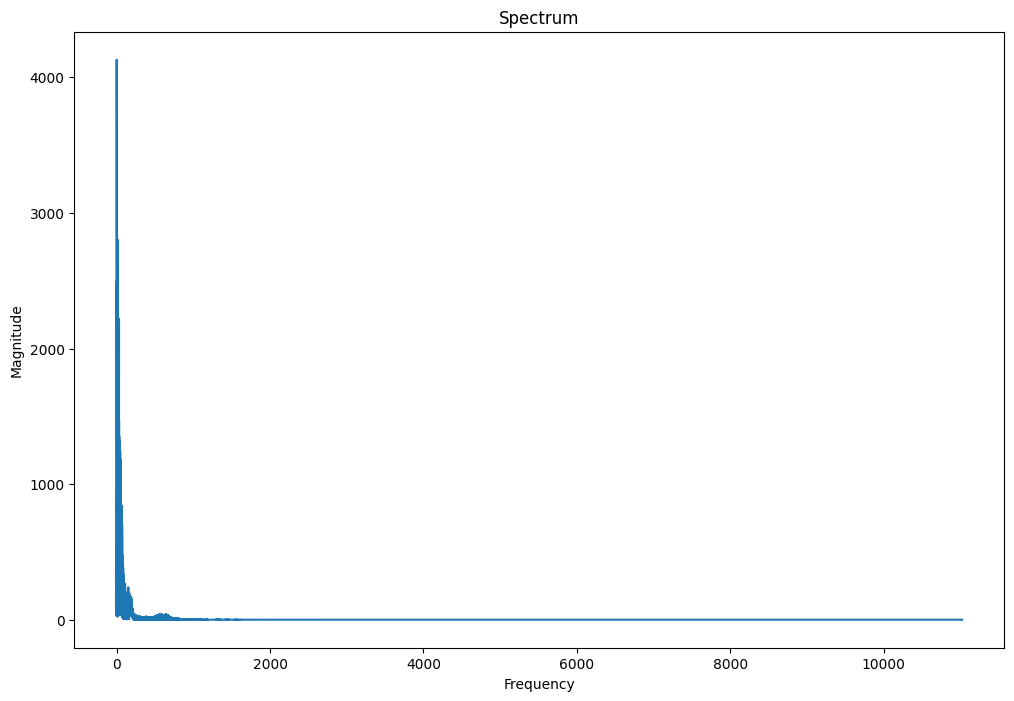

In [19]:
show_audio_spectrum(healthy_sample)

STFT hop length duration is: 0.023219954648526078s
STFT window duration is: 0.09287981859410431s


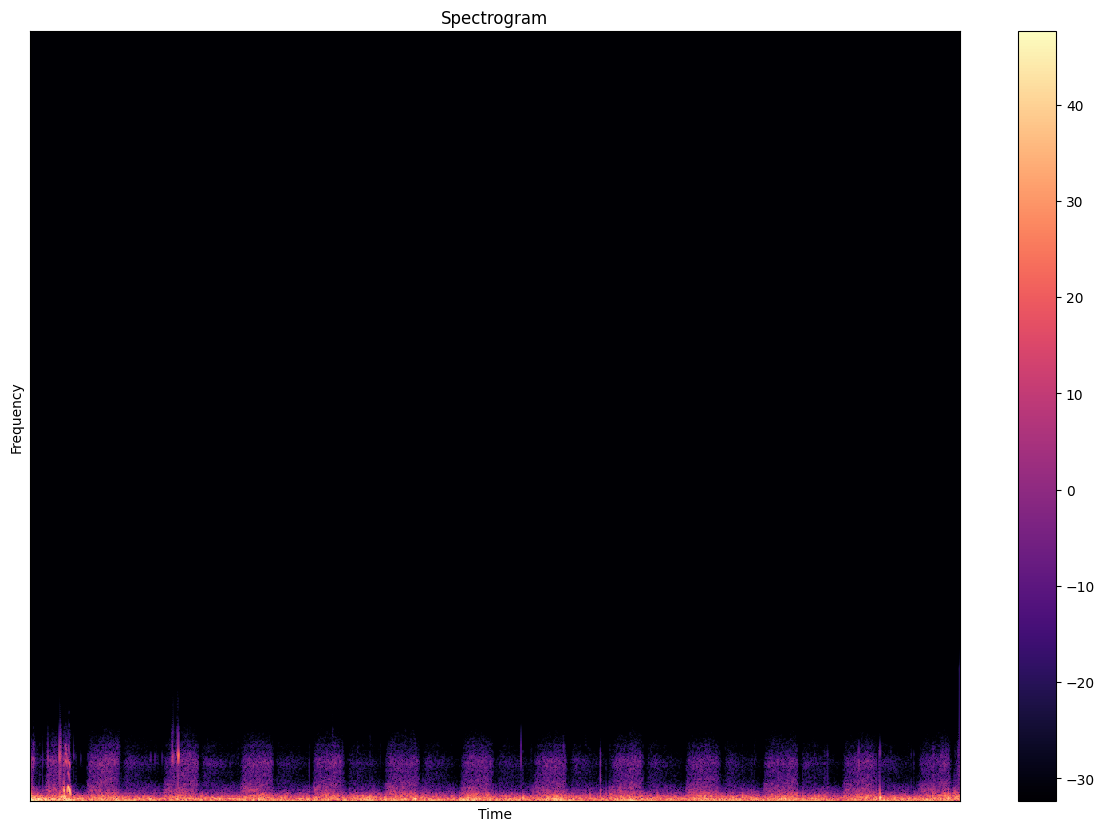

In [20]:
show_spectrogram(healthy_sample)

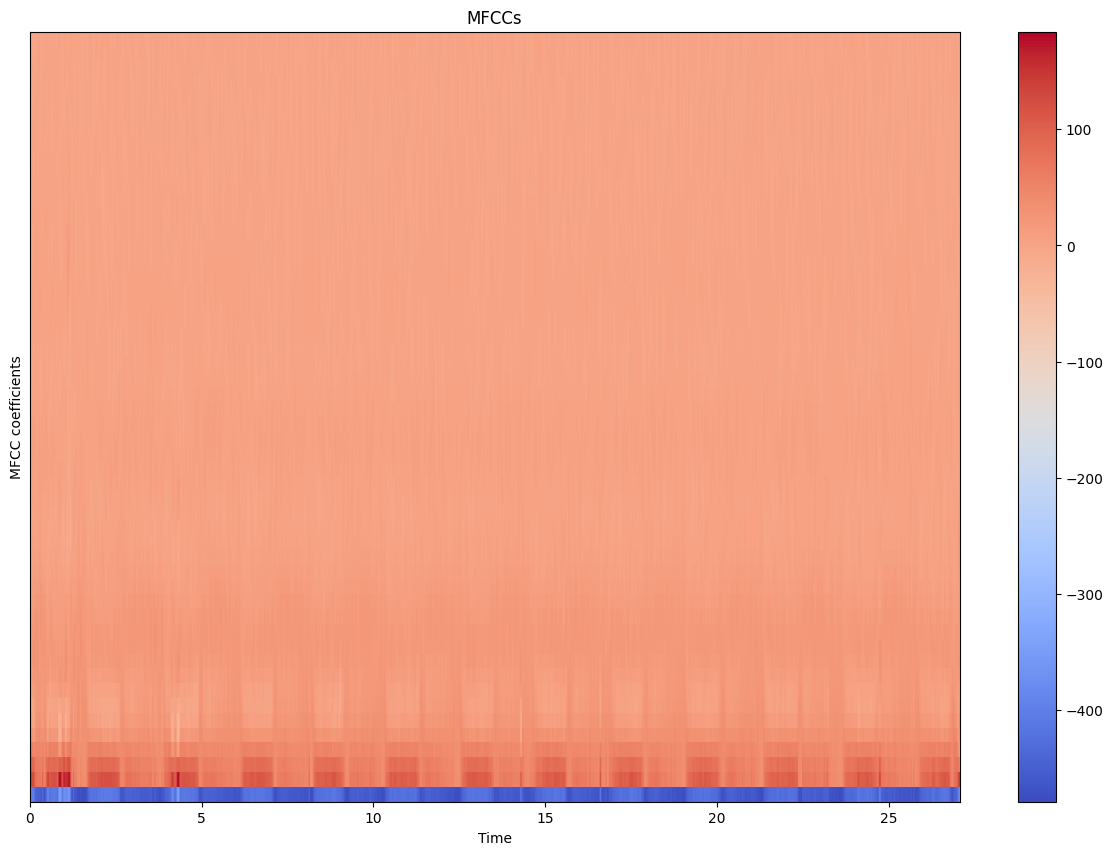

In [21]:
show_mfcc_features(healthy_sample)

In [22]:
def augment_noise(audio, sr=None):
    noise = np.random.randn(len(audio))
    return audio + 0.005 * noise

def augment_pitch(audio, sr):
    return librosa.effects.pitch_shift(audio, sr=sr, n_steps=random.uniform(-2, 2))

def augment_speed(audio, sr):
    speed = random.uniform(0.9, 1.1)
    return librosa.effects.time_stretch(audio, rate=speed)

def apply_augmentations(audio, sr=22050):
    funcs = [
        lambda y: augment_noise(y),
        lambda y: augment_pitch(y, sr),
        lambda y: augment_speed(y, sr)
    ]
    func = random.choice(funcs)
    return func(audio)

In [23]:
class_folders = {
    "Asthma": asthma_data,
    "COPD": copd_data,
    "Healthy": healthy_data
}

def extract_mfcc(audio, sr=22050):
    mfcc = librosa.feature.mfcc(
        y=audio, sr=sr, n_mfcc=52, n_fft=2048, hop_length=512
    )
    return np.mean(mfcc.T, axis=0)


X_features = []
y_labels = []

for label, folder in class_folders.items():
    for file in os.listdir(folder):
        path = os.path.join(folder, file)
        audio, sr = librosa.load(path, sr=22050)
        
        # Orijinal ses
        X_features.append(extract_mfcc(audio))
        y_labels.append(label)

        # Augmented ses
        audio_aug = apply_augmentations(audio)
        X_features.append(extract_mfcc(audio_aug))
        y_labels.append(label)

X = np.array(X_features)
y = np.array(y_labels)

print("Before SMOTE:", X.shape, y.shape)

sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)

print("After SMOTE:", X_res.shape, y_res.shape)

Before SMOTE: (640, 52) (640,)
After SMOTE: (672, 52) (672,)


In [24]:
le = LabelEncoder()
y_encoded = le.fit_transform(y_res)  # string label -> int
y_categorical = to_categorical(y_encoded)  # int -> one-hot (LSTM/RNN için)

X_train, X_test, y_train, y_test = train_test_split(X_res, y_categorical, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [25]:
def build_mlp(input_dim=52, num_classes=3):
    model = Sequential([
        Dense(128, activation='relu', input_dim=input_dim),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(num_classes, activation='softmax')
    ])
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [26]:
def build_lstm(input_shape=(52), num_classes=3):
    model = Sequential()
    model.add(LSTM(64, input_shape=input_shape, return_sequences=False))
    model.add(Dropout(0.3))
    model.add(Dense(num_classes, activation='softmax'))
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

In [27]:
def build_rnn(input_shape=(52, 1), num_classes=3):
    model = Sequential([
        SimpleRNN(64, input_shape=input_shape, return_sequences=False),
        Dropout(0.3),
        Dense(32, activation="relu"),
        Dropout(0.2),
        Dense(num_classes, activation="softmax")
    ])
    
    model.compile(
        optimizer="adam",
        loss="categorical_crossentropy", 
        metrics=["accuracy"]
    )
    
    return model

In [28]:
def build_cnn(input_shape=(52), num_classes = 3):
    model = Sequential()
    model.add(Conv1D(64, kernel_size=3, activation='relu', input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(0.3))
    
    model.add(Conv1D(128, kernel_size=3, activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    model.add(Dropout(0.3))
    
    model.add(Flatten())
    model.add(Dense(256, activation='relu'))
    model.add(Dropout(0.4))
    model.add(Dense(num_classes, activation='softmax'))
    
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

In [29]:
input_shape = (X_train.shape[1], 1)
num_classes = y_train.shape[1]

models = {
    "MLP": build_mlp(input_dim=X_train.shape[1], num_classes=num_classes),
    "LSTM": build_lstm(input_shape=input_shape, num_classes=num_classes),
    "RNN": build_rnn(input_shape=input_shape, num_classes=num_classes),
    "CNN": build_cnn(input_shape=input_shape, num_classes=num_classes)
}

results = {}

for name, model in models.items():
    print("Training:", name)
    
    if name in ["LSTM", "RNN", "CNN"]:
        X_train_reshaped = X_train.reshape(-1, X_train.shape[1], 1)
        X_test_reshaped = X_test.reshape(-1, X_test.shape[1], 1)
        model.fit(X_train_reshaped, y_train,
                  validation_data=(X_test_reshaped, y_test),
                  epochs=100, batch_size=32, verbose=0)
        preds = np.argmax(model.predict(X_test_reshaped), axis=1)
    else:
        model.fit(X_train, y_train,
                  validation_data=(X_test, y_test),
                  epochs=100, batch_size=32, verbose=0)
        preds = np.argmax(model.predict(X_test), axis=1)

    y_true = np.argmax(y_test, axis=1)
    f1 = f1_score(y_true, preds, average="weighted")
    results[name] = f1

    print("F1 Score:", f1)
    print(classification_report(y_true, preds))


c:\Users\MONSTER\Desktop\LungSoundAnlysis\LungSoundAnlysis\venv\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
c:\Users\MONSTER\Desktop\LungSoundAnlysis\LungSoundAnlysis\venv\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)
c:\Users\MONSTER\Desktop\LungSoundAnlysis\LungSoundAnlysis\venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the

Training: MLP
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
F1 Score: 0.6748947691266366
              precision    recall  f1-score   support

           0       0.71      0.65      0.68        54
           1       0.71      0.71      0.71        41
           2       0.60      0.68      0.64        40

    accuracy                           0.67       135
   macro avg       0.67      0.68      0.67       135
weighted avg       0.68      0.67      0.67       135

Training: LSTM
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
F1 Score: 0.5208618042009616
              precision    recall  f1-score   support

           0       0.62      0.54      0.57        54
           1       0.48      0.51      0.49        41
           2       0.45      0.50      0.48        40

    accuracy                           0.52       135
   macro avg       0.52      0.52      0.51       135
weighted avg       0.53      0.52      0.52       135

Training: RNN
1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/stepWARNING:tensorflow:5 ou